# LiDAR Ground Plane Estimation (nuScenes)

This notebook:
- Loads a `.bin` LiDAR point cloud from nuScenes
- Visualizes it
- Estimates the ground plane using RANSAC
- Computes the slope of the ground relative to the sensor


In [1]:
# Install dependencies
#pip install open3d numpy matplotlib

## Load nuScenes point cloud

Each point has format:
`[x, y, z, intensity, ring_index]`

We only use XYZ coordinates.

In [2]:
import numpy as np

def load_nuscenes_bin(file_path):
    points = np.fromfile(file_path, dtype=np.float32)
    points = points.reshape(-1, 5)
    xyz = points[:, :3]
    return xyz

# Update this path
file_path = r'C:\Users\Lars Wissink\OneDrive\Documenten\lars wissink\WB TU Delft\jaar 3\bep\pointcloud.bin'

points = load_nuscenes_bin(file_path)
print('Loaded points:', points.shape)

Loaded points: (34752, 3)


## Visualize lidar data

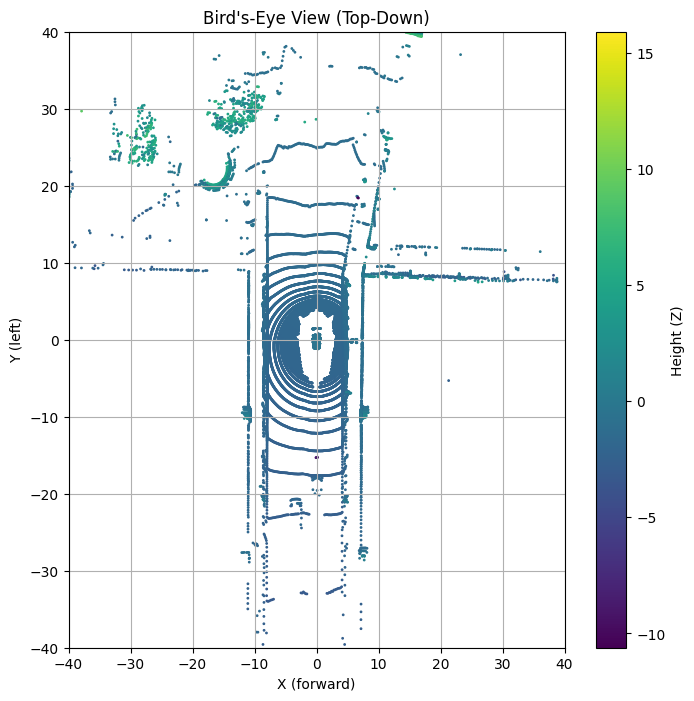

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_bev(points, max_points=100000):

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(
        x, y,
        c=z,                # color by height
        s=1,                # point size
    )

    plt.colorbar(scatter, label="Height (Z)")

    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("Bird's-Eye View (Top-Down)")

    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)

    plt.show()

visualize_bev(points)

## Estimate ground plane (RANSAC)

Fits a plane: ax + by + cz + d = 0

In [4]:
import open3d as o3d
import numpy as np

def estimate_ground_plane_bottom(points, bottom_fraction=0.2):
    """
    Estimate the ground plane using only the bottom fraction of points (by height).

    Args:
        points: Nx3 array of LiDAR points
        bottom_fraction: fraction of points (lowest Z) to use for plane fitting
    """
    # Select bottom fraction by Z
    z_threshold = np.percentile(points[:,2], bottom_fraction*100)
    bottom_points = points[points[:,2] <= z_threshold]

    print(f"Using {len(bottom_points)} points ({bottom_fraction*100:.0f}% lowest) for ground estimation.")

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(bottom_points)

    # RANSAC plane fit
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=0.2,
        ransac_n=3,
        num_iterations=1000
    )

    a, b, c, d = plane_model
    print(f'Plane equation: {a:.4f}x + {b:.4f}y + {c:.4f}z + {d:.4f} = 0')

    # Map inliers back to original points (optional)
    # Here, inliers are indices in bottom_points
    # You could convert to indices in full points if needed

    return plane_model, inliers, bottom_points

# Usage
plane_model, inliers, bottom_points = estimate_ground_plane_bottom(points, bottom_fraction=0.2)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Using 6951 points (20% lowest) for ground estimation.
Plane equation: -0.0071x + -0.0299y + 0.9995z + 1.8797 = 0


## Compute slope of ground plane

- Plane normal = (a, b, c)
- Compare with vertical axis (0,0,1)
- Output slope in degrees

In [5]:
import numpy as np

def compute_slope_fixed(plane_model):
    a, b, c, d = plane_model

    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    z_axis = np.array([0, 0, 1])

    # angle between normal and vertical
    angle_rad = np.arccos(np.clip(np.dot(normal, z_axis), -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)

    slope_deg = angle_deg  # small tilt = small slope

    print(f'Angle between normal and vertical: {angle_deg:.2f}°')
    print(f'Ground slope: {slope_deg:.2f}°')

    return slope_deg

# Usage
slope = compute_slope_fixed(plane_model)

Angle between normal and vertical: 1.76°
Ground slope: 1.76°


# Visualize vertical distance to the ground plane

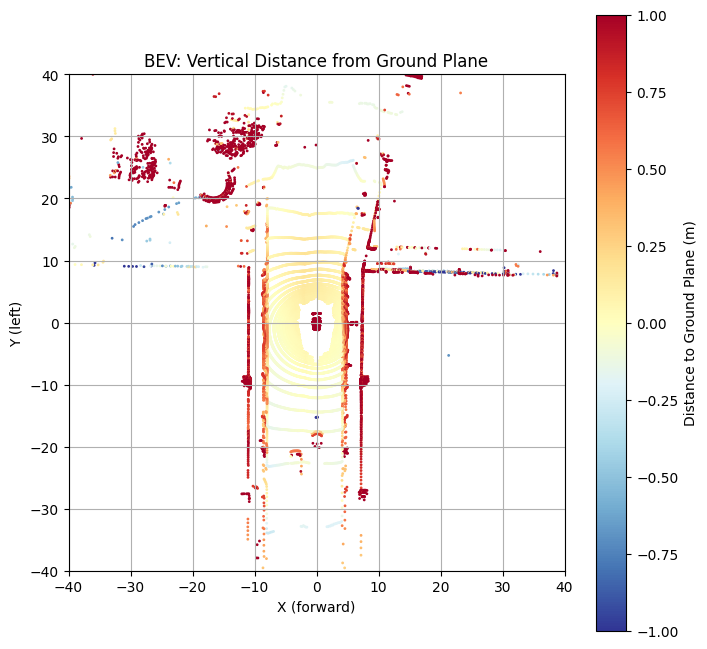

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_bev_distance(points, plane_model, max_points=100000, distance_clip=1.0):
    """
    BEV plot (X-Y) where color encodes vertical distance from the ground plane.

    Args:
        points: Nx3 LiDAR points
        plane_model: [a, b, c, d] plane coefficients
        max_points: maximum points to plot (for speed)
        distance_clip: max abs distance to visualize (m)
    """
    a, b, c, d = plane_model

    # Normalize plane
    norm = np.linalg.norm([a, b, c])
    a, b, c, d = a/norm, b/norm, c/norm, d/norm
    normal = np.array([a, b, c])

    # Signed vertical distance
    distances = points @ normal + d

    x = points[:,0]
    y = points[:,1]

    # Clip distances for visualization
    distances = np.clip(distances, -distance_clip, distance_clip)

    plt.figure(figsize=(8,8))

    sc = plt.scatter(
        x, y,
        c=distances,
        s=1,
        cmap='RdYlBu_r'  # red=above plane, blue=below
    )

    plt.colorbar(sc, label="Distance to Ground Plane (m)")
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("BEV: Vertical Distance from Ground Plane")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)
    plt.show()

# Usage
visualize_bev_distance(points, plane_model)

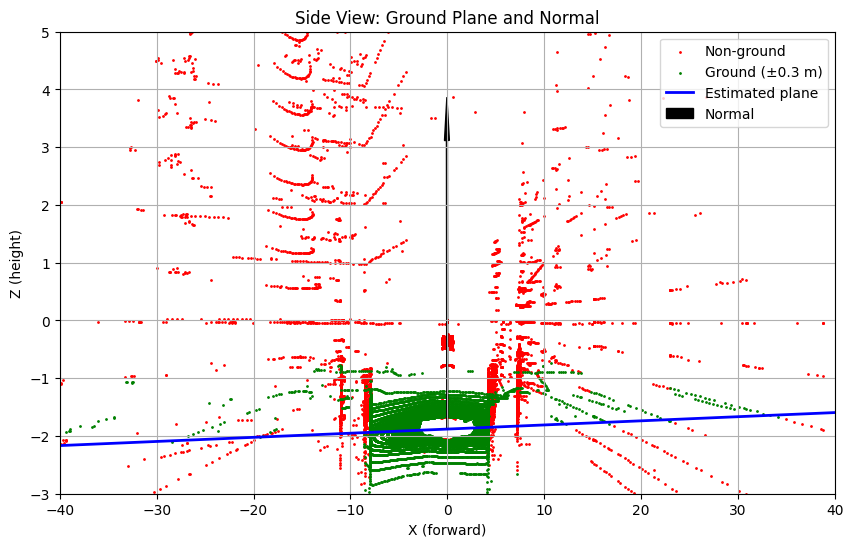

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_ground_plane_side(points, plane_model, distance_thresh=0.3):
    """
    Side view (X-Z) showing:
    - ground points (green)
    - other points (red)
    - estimated plane (blue line)
    - normal vector (black arrow)
    """

    a, b, c, d = plane_model

    # Normalize plane normal
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)
    a, b, c = normal

    # Signed distance of each point to plane
    distances = points @ normal + d
    inliers = np.abs(distances) < distance_thresh

    x = points[:,0]
    z = points[:,2]

    plt.figure(figsize=(10,6))

    # Plot points
    plt.scatter(x[~inliers], z[~inliers], s=1, color='red', label='Non-ground')
    plt.scatter(x[inliers], z[inliers], s=1, color='green', label=f'Ground (±{distance_thresh} m)')

    # Plane line (Y≈0 slice)
    xs = np.linspace(-40, 40, 500)
    zs = (-a*xs - d)/c
    plt.plot(xs, zs, color='blue', linewidth=2, label='Estimated plane')

    # Normal vector from point on plane at x=0, y=0
    origin = np.array([0, 0, -d/c])
    scale = 5
    normal_end = origin + normal * scale
    plt.arrow(
        origin[0], origin[2],
        normal[0]*scale, normal[2]*scale,
        color='black', width=0.1, head_width=0.5,
        label='Normal'
    )

    plt.xlabel("X (forward)")
    plt.ylabel("Z (height)")
    plt.title("Side View: Ground Plane and Normal")
    plt.xlim(-40, 40)
    plt.ylim(-3, 5)
    plt.grid(True)
    plt.legend()
    plt.show()

# Usage
visualize_ground_plane_side(points, plane_model)

# Grid-based Ground Curvature Estimation

Divides the point cloud into a grid of cells. For each cell:
- Selects points near the reference ground plane
- Fits a local plane using RANSAC
- Computes the local slope relative to vertical

The result is a curvature map showing how the ground tilts across the scene.

Fitted local planes in 252 polar cells


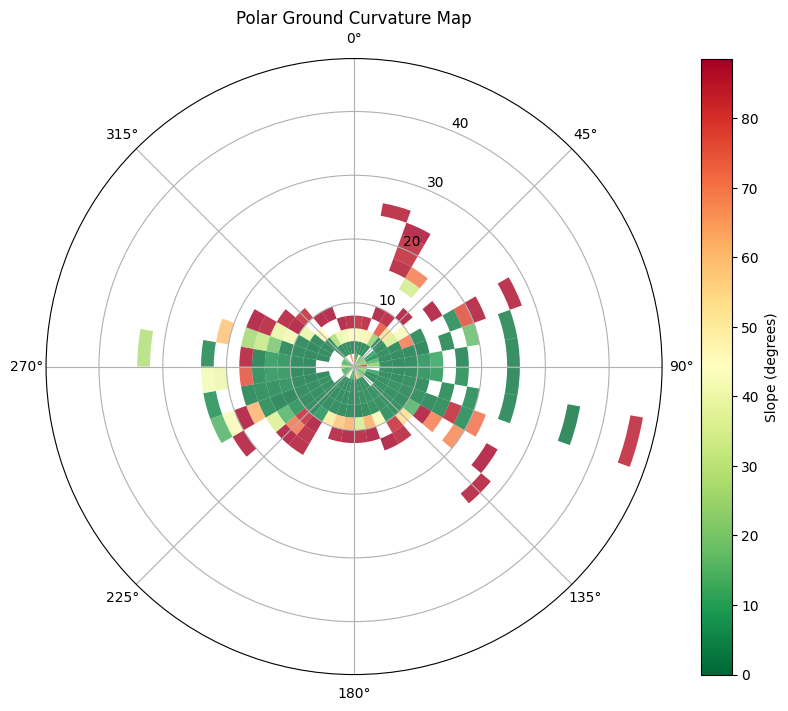

[{'r_mid': 1.0, 'theta_mid': -3.0543261909900767, 'r_bounds': (0.0, 2.0), 'theta_bounds': (-3.141592653589793, -2.9670597283903604), 'slope': 11.236301168285625, 'normal': array([-0.17451183,  0.08668571,  0.9808319 ])}, {'r_mid': 1.0, 'theta_mid': -2.879793265790644, 'r_bounds': (0.0, 2.0), 'theta_bounds': (-2.9670597283903604, -2.792526803190927), 'slope': 10.659815009204758, 'normal': array([-0.17381326,  0.06328975,  0.98274277])}, {'r_mid': 1.0, 'theta_mid': -2.5307274153917776, 'r_bounds': (0.0, 2.0), 'theta_bounds': (-2.6179938779914944, -2.443460952792061), 'slope': 38.86961293116579, 'normal': array([-0.62503031, -0.05618182,  0.77857608])}, {'r_mid': 1.0, 'theta_mid': -2.356194490192345, 'r_bounds': (0.0, 2.0), 'theta_bounds': (-2.443460952792061, -2.2689280275926285), 'slope': 17.499284077505994, 'normal': array([-0.16529335, -0.25118702,  0.95372071])}, {'r_mid': 1.0, 'theta_mid': -2.181661564992912, 'r_bounds': (0.0, 2.0), 'theta_bounds': (-2.2689280275926285, -2.094395102

In [24]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

def compute_polar_grid_slopes(points, plane_model, r_step=5.0, theta_step_deg=15.0, 
                              distance_thresh=-20, min_points=10):
    """
    Divide point cloud into polar 'wedges', fit local planes, and compute slopes.
    """
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    # 1. Isolate ground points
    distances = points @ normal + d
    ground_points = points[np.abs(distances) < distance_thresh]
    
    # 2. Convert to Polar
    x = ground_points[:, 0]
    y = ground_points[:, 1]
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x) # Result in radians [-pi, pi]

    # Define bins
    r_bins = np.arange(0, r.max() + r_step, r_step)
    theta_bins = np.deg2rad(np.arange(-180, 180 + theta_step_deg, theta_step_deg))

    z_axis = np.array([0, 0, 1])
    results = []

    # 3. Iterate through polar cells
    for i in range(len(r_bins) - 1):
        for j in range(len(theta_bins) - 1):
            mask = (
                (r >= r_bins[i]) & (r < r_bins[i+1]) &
                (theta >= theta_bins[j]) & (theta < theta_bins[j+1])
            )
            cell_pts = ground_points[mask]

            if len(cell_pts) < min_points:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(cell_pts)

            try:
                local_plane, _ = pcd.segment_plane(0.1, 3, 100)
                la, lb, lc, _ = local_plane
                l_norm = np.array([la, lb, lc])
                l_norm /= np.linalg.norm(l_norm)

                # Ensure normal points 'up'
                if l_norm[2] < 0: l_norm = -l_norm

                slope = np.degrees(np.arccos(np.clip(np.dot(l_norm, z_axis), -1, 1)))
                
                # Store geometry for plotting
                results.append({
                    'r_mid': (r_bins[i] + r_bins[i+1]) / 2,
                    'theta_mid': (theta_bins[j] + theta_bins[j+1]) / 2,
                    'r_bounds': (r_bins[i], r_bins[i+1]),
                    'theta_bounds': (theta_bins[j], theta_bins[j+1]),
                    'slope': slope,
                    'normal': l_norm
                })
            except:
                continue
    return results

def visualize_polar_curvature(results, r_step, theta_step_deg):
    if not results: return

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')

    # Extract data
    slopes = np.array([res['slope'] for res in results])
    vmax = np.percentile(slopes, 95)
    cmap = plt.get_cmap('RdYlGn_r')

    # 4. Draw Annular Sectors
    for res in results:
        r0, r1 = res['r_bounds']
        t0, t1 = res['theta_bounds']
        
        # Draw the filled wedge
        ax.bar(t0, r1-r0, width=t1-t0, bottom=r0, 
               color=cmap(res['slope']/vmax), align='edge', alpha=0.8)

    # 5. Add orientation markers
    ax.set_theta_zero_location('N') # Set 0° (Forward/X) to North
    ax.set_theta_direction(-1)      # Clockwise
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    plt.colorbar(sm, ax=ax, label='Slope (degrees)')
    plt.title("Polar Ground Curvature Map")
    plt.show()

# --- Parameters ---
R_STEP          = 2.0   # Meters per radial "ring"
THETA_STEP      = 10.0  # Degrees per angular "wedge"
DIST_THRESH     = 1.8 # Max distance from reference plane
MIN_POINTS_CELL = 15    # Minimum points to fit a plane

# 1. Compute the slopes using the polar logic
polar_results = compute_polar_grid_slopes(
    points, 
    plane_model,
    r_step=R_STEP, 
    theta_step_deg=THETA_STEP,
    distance_thresh=DIST_THRESH, 
    min_points=MIN_POINTS_CELL
)

print(f"Fitted local planes in {len(polar_results)} polar cells")

# 2. Visualize using the polar projection
visualize_polar_curvature(polar_results, R_STEP, THETA_STEP)
print(polar_results)

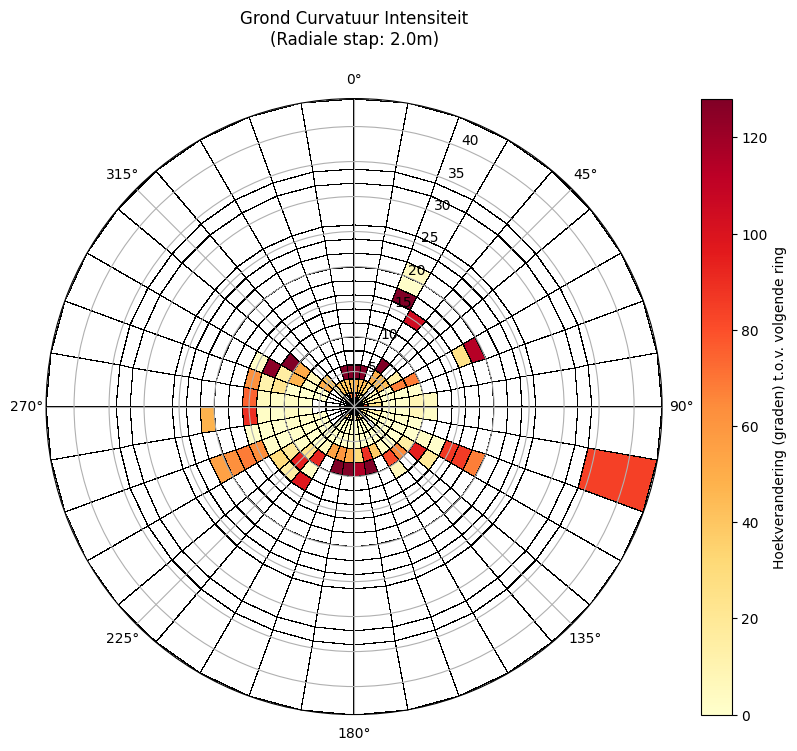

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_direct_polar_curvature(results, r_step):
    """
    Berekent de hoekverandering tussen opeenvolgende ringen en 
    geeft dit weer in een polaire hittekaart (zoals je afbeelding).
    """
    if not results:
        print("Geen resultaten gevonden.")
        return

    # 1. Data organiseren voor snelle lookup
    r_starts = sorted(list(set(res['r_bounds'][0] for res in results)))
    t_starts = sorted(list(set(res['theta_bounds'][0] for res in results)))
    t_ends = sorted(list(set(res['theta_bounds'][1] for res in results)))
    
    # Maak een map: (r_waarde, t_waarde) -> normaalvector
    data_map = {(res['r_bounds'][0], res['theta_bounds'][0]): res['normal'] for res in results}

    # 2. Curvatuur matrix opbouwen (Verschil tussen ring i en i+1)
    # We hebben (N-1) rijen aan data voor N ringen
    num_r = len(r_starts)
    num_t = len(t_starts)
    curvature_matrix = np.full((num_r - 1, num_t), np.nan)

    for i in range(num_r - 1):
        r_curr = r_starts[i]
        r_next = r_starts[i+1]
        for j in range(num_t):
            t_curr = t_starts[j]
            
            n1 = data_map.get((r_curr, t_curr))
            n2 = data_map.get((r_next, t_curr))
            
            if n1 is not None and n2 is not None:
                # Bereken hoekverschil in graden
                dot = np.clip(np.dot(n1, n2), -1.0, 1.0)
                curvature_matrix[i, j] = np.degrees(np.arccos(dot))

    # 3. Plotten in Polair formaat
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # Oriëntatie: 0 graden is Vooruit (+X)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Definieer de grenzen voor de vakjes (edges)
    # Theta grenzen: alle startpunten + het allerlaatste eindpunt
    t_boundaries = np.array(t_starts + [t_ends[-1]])
    # R grenzen: we gebruiken de eerste (N-1) ringen omdat we daar curvatuur voor hebben
    r_boundaries = np.array(r_starts)

    # De hittekaart tekenen
    mesh = ax.pcolormesh(t_boundaries, r_boundaries, curvature_matrix, 
                         cmap='YlOrRd', shading='flat', edgecolor='black', linewidth=0.1)
    
    # Kleurenschaal instellen (automatisch op 95e percentiel voor goed contrast)
    valid_vals = curvature_matrix[~np.isnan(curvature_matrix)]
    if len(valid_vals) > 0:
        vmax = np.percentile(valid_vals, 95)
        mesh.set_clim(0, max(vmax, 2.0)) # Minimaal 2 graden schaal voor leesbaarheid

    plt.colorbar(mesh, ax=ax, label='Hoekverandering (graden) t.o.v. volgende ring')
    ax.set_title(f"Grond Curvatuur Intensiteit\n(Radiale stap: {r_step}m)", pad=20)
    plt.show()

# --- Uitvoeren ---
# Gebruik de resultaten uit je eerdere polar_results berekening
plot_direct_polar_curvature(polar_results, R_STEP)